# Statistics

## Load Model

In [1]:
from wings.modeling.loss import DiceLoss, WeightedDiceLoss, BCEDiceLoss
from wings.modeling.litnet import LitNet
from wings.config import PROCESSED_DATA_DIR, MODELS_DIR
from wings.dataset import MaskRectangleDataset
from wings.modeling.unet import UNet
import torch
from ultralytics import YOLO

mean_coords = torch.load(
    PROCESSED_DATA_DIR / "mask_datasets" / 'rectangle' / "mean_shape.pth", weights_only=False
)

# checkpoint_path = MODELS_DIR / "new_unet" / "custom-unet-pretrained-epoch=49-val_loss=0.02-custom-unet-training_1.ckpt"
# checkpoint_path = MODELS_DIR / "new_unet" / "last.ckpt" # ten last to nie jest prawdziwy last tylko jakis z 54 epoki
# checkpoint_path = MODELS_DIR / "new_unet" / "unet-400-from-pretrained-epoch=57-val_loss=0.02-unet-400_1.ckpt"
# checkpoint_path = MODELS_DIR / "new_unet" / "kernel5.ckpt"
# checkpoint_path = MODELS_DIR / "new_unet" / "last-v1-kernel.ckpt"
# checkpoint_path = MODELS_DIR / "new_unet" / "unet-final-k3.ckpt"
checkpoint_path = MODELS_DIR / "new_unet" / "unet-final-k5.ckpt"

unet_model = UNet(in_channels=1, out_channels=1, kernel_size=5)
# model = LitNet.load_from_checkpoint(checkpoint_path, model=unet_model, criterion=WeightedDiceLoss(landmark_weight=50.0, background_weight=1.0))
model = LitNet.load_from_checkpoint(checkpoint_path, model=unet_model, criterion=BCEDiceLoss(), strict=False)
model.eval()


yolo_model = YOLO(MODELS_DIR / "yolo26n" / "best.pt").to("cuda")
# yolo_model = YOLO(MODELS_DIR / "yolo26n" / "detector.onnx", task="detect")
# yolo_model = YOLO(MODELS_DIR / "best.pt").to("cuda")


2026-06-26 13:23:22.268 | INFO     | wings.config:<module>:44 - PROJ_ROOT path is: C:\Users\X\projects\bees
2026-06-26 13:23:24.167 | INFO     | wings.config:<module>:68 - torch.cuda.get_device_name()='NVIDIA RTX A3000 12GB Laptop GPU'
W0626 13:23:40.939000 43312 .venv\Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


# Test dataset

In [3]:
test_dataset = torch.load(
    PROCESSED_DATA_DIR / "mask_datasets" / 'rectangle-cropped' / "test_mask_dataset_ch1_400.pth",
    weights_only=False
)
max_n = len(test_dataset)
max_n


2172

In [4]:
from wings.gpa import recover_order, center_shape, normalize_shape, procrustes_align
from wings.visualizing.image_preprocess import final_coords
from wings.gpa import handle_coordinates
import torch
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

original_labels = [[] for _ in range(5)]
predicted_labels = [[] for _ in range(5)]
points_indices = [[] for _ in range(5)]

for idx, (image, _, coords, (x_size, y_size)) in enumerate(tqdm(test_dataset, desc="Evaluating")):
    image = image.to(device).unsqueeze(0)
    output = model(image)
    mask = torch.round(output).squeeze().detach().cpu().numpy()
    mask_coords = final_coords(mask, x_size, y_size)
    mask_coords = torch.tensor(mask_coords)
    n_points = len(mask_coords)

    if n_points < 18:
        idx_group = 0
    elif n_points == 18:
        idx_group = 1
    elif n_points == 19:
        idx_group = 2
    elif n_points == 20:
        idx_group = 3
    else:
        idx_group = 4

    reordered = handle_coordinates(mask_coords, mean_coords).cpu().numpy()
    orig = coords.view(-1, 2)

    points_indices[idx_group].append(idx)
    original_labels[idx_group].append(orig.cpu().numpy())
    predicted_labels[idx_group].append(reordered)



original_labels = [np.stack(lbls) if len(lbls) > 0 else np.empty((0, 2)) for lbls in original_labels]
predicted_labels = [
    np.stack(lbls) if len(lbls) > 0 else np.empty((0, 0, 2)) for lbls in predicted_labels
]


total_samples_num = len(test_dataset)
failed_samples_num = sum(len(points_indices[i]) for i in [0, 1, 3, 4])  # exclude 19-points group

print(f"Total samples: {total_samples_num}")
print(f"Failed masks: {failed_samples_num}")

for i, n_points in enumerate(range(17, 22)):
    print(f"predicted_labels_{n_points}.shape = {predicted_labels[i].shape}")



errors = []
for i in range(5):
    if len(predicted_labels[i]) == 0 or len(original_labels[i]) == 0:
        errors.append(np.empty((0, 0)))
        continue
    err = np.linalg.norm(predicted_labels[i] - original_labels[i], axis=2)
    errors.append(err)

# Compute means and medians
for i, n_points in enumerate(range(17, 22)):
    if errors[i].size == 0:
        print(f"{n_points}-point group: no samples available.")
        continue
    mean_val = errors[i].mean()
    median_val = np.median(errors[i])
    num_img = len(errors[i])  # total number of point-wise errors

    print(f"mean{n_points}={mean_val:.4f}\tmedian{n_points}={median_val:.4f}\t\timages={num_img}")



# ---- GLOBAL ERROR ACROSS ALL GROUPS ----
# Flatten all non-empty error arrays into a single array
all_errors = np.concatenate([e.flatten() for e in errors if e.size > 0])

if all_errors.size > 0:
    global_mean = all_errors.mean()
    global_median = np.median(all_errors)
    print(f"\nGLOBAL MEAN ERROR = {global_mean:.4f}")
    print(f"GLOBAL MEDIAN ERROR = {global_median:.4f}")
else:
    print("\nNo valid error data available for global computation.")


Evaluating: 100%|██████████| 2172/2172 [01:13<00:00, 29.48it/s]

Total samples: 2172
Failed masks: 12
predicted_labels_17.shape = (0, 0, 2)
predicted_labels_18.shape = (7, 19, 2)
predicted_labels_19.shape = (2160, 19, 2)
predicted_labels_20.shape = (4, 19, 2)
predicted_labels_21.shape = (1, 19, 2)
17-point group: no samples available.
mean18=1.4769	median18=1.1386		images=7
mean19=1.0599	median19=0.9683		images=2160
mean20=1.4256	median20=1.3413		images=4
mean21=1.7974	median21=1.7348		images=1

GLOBAL MEAN ERROR = 1.0622
GLOBAL MEDIAN ERROR = 0.9694


In [5]:
from wings.detection.dataset import collect_image_paths
from wings.config import RAW_DATA_DIR, COUNTRIES

image_paths = collect_image_paths(RAW_DATA_DIR, COUNTRIES)
import random

sample_path = random.choice(image_paths)
sample_path = RAW_DATA_DIR / "PL-wings-images" / "PL-0012-000270-L.dw.png"
sample_path


2026-05-14 11:28:04.294 | INFO     | wings.detection.dataset:collect_image_paths:30 - Collecting image paths from: C:\Users\X\projects\bees\data\raw


WindowsPath('C:/Users/X/projects/bees/data/raw/PL-wings-images/PL-0012-000270-L.dw.png')

In [35]:
from wings.config import RAW_DATA_DIR
import random
import os
from PIL import Image
from pathlib import Path


directory = RAW_DATA_DIR / "pulawy" / "01_00_01"

image_paths = []
for subdir, _, files in os.walk(directory):
    for file in files:
        if file.lower().endswith(".png"):
            path = Path(os.path.join(subdir, file))

            with Image.open(path) as img:
                x_size, y_size = img.size

            if x_size == 5782:
                continue

            image_paths.append(path)


sample_path = random.choice(image_paths)
sample_path

WindowsPath('C:/Users/X/projects/bees/data/raw/pulawy/01_00_01/01_00_18/01_00_477.png')

Loading C:\Users\X\projects\bees\models\yolo26n\detector.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.25.1 with CUDAExecutionProvider
(247, 657, 3)
[[        181         141]
 [        196         144]
 [        252          62]
 [        254         114]
 [        260         203]
 [        324          58]
 [        375          25]
 [        361          50]
 [        395          83]
 [        366         103]
 [        413         134]
 [        415         177]
 [        430         208]
 [        443          35]
 [        478          73]
 [        557         111]
 [        591         114]
 [        601         141]
 [         56          71]]


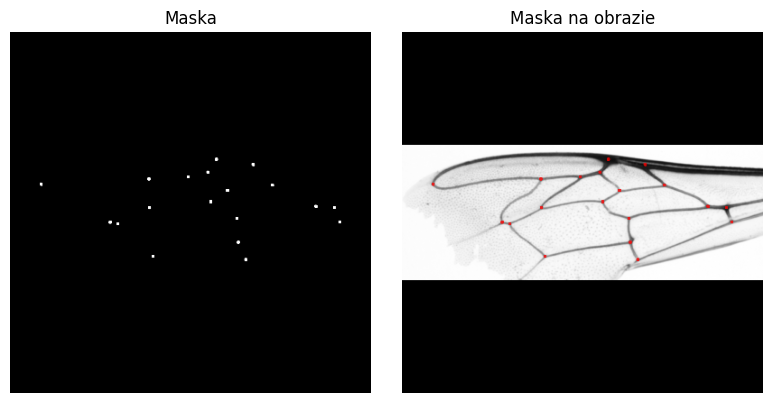

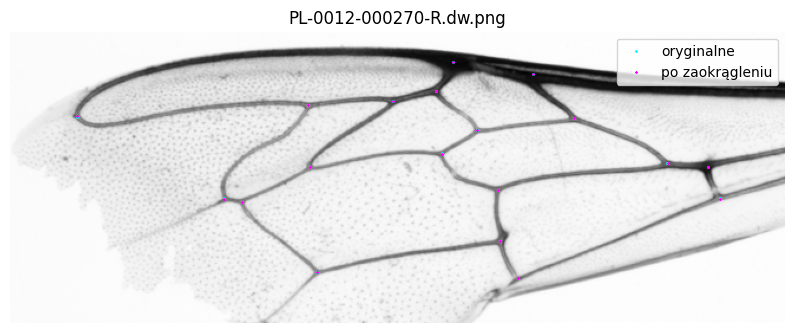

In [41]:
from wings.gpa import handle_coordinates
from wings.visualizing.image_preprocess import final_coords, unet_fit_rectangle_preprocess
import torch
import numpy as np
from tqdm import tqdm
import cv2
from functools import partial

preprocess = partial(unet_fit_rectangle_preprocess, output_size=400)



sample_path = random.choice(image_paths)
sample_path = RAW_DATA_DIR / "PL-wing-images" / "PL-0001-000420-L.dw.png"
sample_path = RAW_DATA_DIR / "PL-wing-images" / "PL-0012-000270-R.dw.png"
img = cv2.imread(str(sample_path))
result = yolo_model.predict(img, verbose=False)[0]
if len(result) > 0:
    boxes = result.boxes.cpu().numpy()
    conf = boxes.conf
    x1, y1, x2, y2 = boxes.xyxy[np.argmax(conf)]

    xmin, xmax = int(min(x1, x2)), int(max(x1, x2))
    ymin, ymax = int(min(y1, y2)), int(max(y1, y2))

    img = img[ymin:ymax, xmin:xmax]

print(img.shape)


img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_tensor = torch.from_numpy(img).unsqueeze(0).contiguous()
x_size, y_size = img_tensor.shape[2], img_tensor.shape[1]
image_tensor, _, _ = preprocess(img_tensor)

output = model(image_tensor.cuda().unsqueeze(0))
mask = torch.round(output).squeeze().detach().cpu().numpy()
mask_coords = final_coords(mask, x_size, y_size)
mask_coords = torch.tensor(mask_coords)
reordered = handle_coordinates(mask_coords, mean_coords).cpu().numpy()

rounded = reordered.round().copy()
rounded[:, 1] = y_size - rounded[:, 1] - 1
print(rounded)

import matplotlib.pyplot as plt
import numpy as np

mask = output.squeeze().detach().cpu().numpy()
tensor_img = image_tensor.squeeze().detach().cpu().numpy()
raw_img = img  # surowy crop po YOLO, przed preprocess

pts = np.asarray(reordered).reshape(-1, 2).copy()

# Landmarki po zaokrągleniu
pts_rounded = pts.round().copy()

# odbicie składowej y dla obu wersji
pts[:, 1] = raw_img.shape[0] - pts[:, 1] - 1
pts_rounded[:, 1] = raw_img.shape[0] - pts_rounded[:, 1] - 1

red_overlay = np.zeros((*mask.shape, 4))
red_overlay[..., 0] = 1.0
red_overlay[..., 3] = mask * 0.8

# poprzednie ploty zostają
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(mask, cmap="gray")
plt.title("Maska")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tensor_img, cmap="gray")
plt.imshow(red_overlay)
plt.title("Maska na obrazie")
plt.axis("off")

plt.tight_layout()
plt.show()

# trzecia figura: oryginalne + zaokrąglone landmarki
plt.figure(figsize=(10, 10))
plt.imshow(raw_img, cmap="gray")

plt.scatter(
    pts[:, 0],
    pts[:, 1],
    c="cyan",
    s=1,
    label="oryginalne"
)

plt.scatter(
    pts_rounded[:, 0],
    pts_rounded[:, 1],
    c="magenta",
    s=1,
    marker="x",
    label="po zaokrągleniu"
)

plt.title(f"{sample_path.name}")
plt.legend()
plt.axis("off")
plt.show()

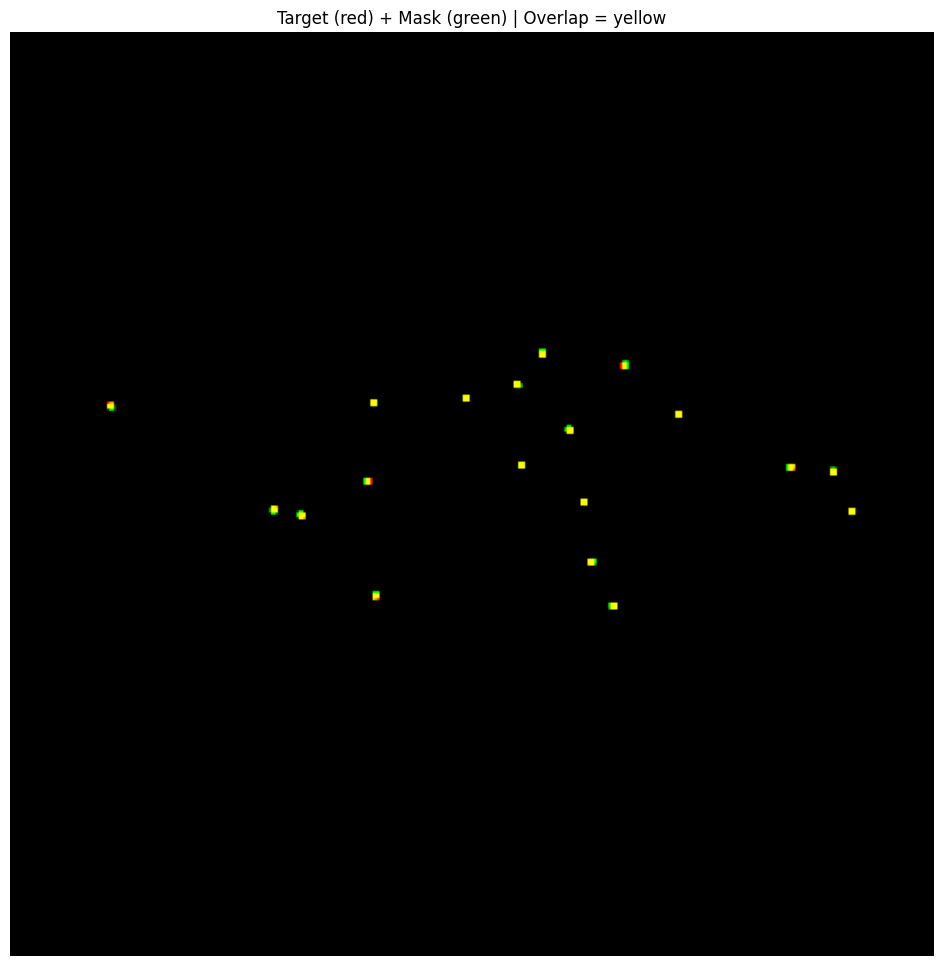

In [111]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch

n = random.randint(0, max_n - 1)

image, target, coords, (x_size, y_size) = test_dataset[n]

image = image.to(device).unsqueeze(0)

with torch.no_grad():
    output = model(image)

target_np = target.squeeze().detach().cpu().numpy().astype(np.float32)
mask_np = output.squeeze().detach().cpu().numpy().astype(np.float32)

# normalizacja do [0, 1] jeśli potrzeba
if target_np.min() < 0 or target_np.max() > 1:
    target_np = (target_np - target_np.min()) / (target_np.max() - target_np.min() + 1e-8)

if mask_np.min() < 0 or mask_np.max() > 1:
    mask_np = (mask_np - mask_np.min()) / (mask_np.max() - mask_np.min() + 1e-8)

# czarne tło, target = czerwony, maska = zielony, overlap = żółty
overlay = np.zeros((*target_np.shape, 3), dtype=np.float32)
overlay[..., 0] = target_np   # red
overlay[..., 1] = mask_np     # green

plt.figure(figsize=(12, 12))
plt.imshow(np.clip(overlay, 0, 1))
plt.title("Target (red) + Mask (green) | Overlap = yellow")
plt.axis("off")
plt.show()

# Puławy

In [13]:
from wings.config import RAW_DATA_DIR
import random
import os
from PIL import Image
from pathlib import Path


directory = RAW_DATA_DIR / "pulawy" / "01_00_01"

all_files = []
for subdir, _, files in os.walk(directory):
    for file in files:
        if file.lower().endswith(".png"):
            path = Path(os.path.join(subdir, file))

            with Image.open(path) as img:
                x_size, y_size = img.size

            if x_size == 5782:
                continue

            all_files.append(path)


sample_path = random.choice(all_files)
sample_path

WindowsPath('C:/Users/X/projects/bees/data/raw/pulawy/01_00_01/01_00_10/01_00_267.png')

In [14]:
from PIL import Image
from wings.gpa import handle_coordinates
from wings.visualizing.image_preprocess import final_coords, unet_fit_rectangle_preprocess
import torch
import numpy as np
from tqdm import tqdm
import cv2
from functools import partial

original_labels = [[] for _ in range(5)]
predicted_labels = [[] for _ in range(5)]
points_indices = [[] for _ in range(5)]
negative_coords = []

preprocess = partial(unet_fit_rectangle_preprocess, output_size=400)

for idx, img_path in enumerate(tqdm(all_files, desc="Processing images")):
    img = Image.open(img_path)
    img.load()
    meta = img.info['IdentiFly']
    orig = meta.split("landmarks:")[1].split(";")[0]
    labels = np.array([int(x) for x in orig.split()])
    x_coords, y_coords = labels[::2], labels[1::2]
    img = cv2.imread(str(img_path))
    result = yolo_model.predict(img, verbose=False)[0]
    if len(result) > 0:
        boxes = result.boxes.cpu().numpy()
        conf = boxes.conf
        x1, y1, x2, y2 = boxes.xyxy[np.argmax(conf)]

        xmin, xmax = int(min(x1, x2)), int(max(x1, x2))
        ymin, ymax = int(min(y1, y2)), int(max(y1, y2))

        img = img[ymin:ymax, xmin:xmax]
        x_coords = x_coords - xmin
        y_coords = y_coords - ymin

    if (x_coords < 0).any() or (y_coords < 0).any():
        negative_coords.append(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_tensor = torch.from_numpy(img).unsqueeze(0).contiguous()
    x_size, y_size = img_tensor.shape[2], img_tensor.shape[1]
    image_tensor, _, _ = preprocess(img_tensor)

    output = model(image_tensor.cuda().unsqueeze(0))
    mask = torch.round(output).squeeze().detach().cpu().numpy()
    mask_coords = final_coords(mask, x_size, y_size)
    mask_coords = torch.tensor(mask_coords)
    n_points = len(mask_coords)

    if n_points < 18:
        idx_group = 0
    elif n_points == 18:
        idx_group = 1
    elif n_points == 19:
        idx_group = 2
    elif n_points == 20:
        idx_group = 3
    else:
        idx_group = 4

    reordered = handle_coordinates(mask_coords, mean_coords).cpu().numpy()
    x_coords = torch.tensor(x_coords)
    y_coords = torch.tensor(y_coords)
    y_coords = y_size - y_coords - 1
    orig = torch.stack((x_coords, y_coords), dim=1)


    points_indices[idx_group].append(img_path)
    original_labels[idx_group].append(orig.cpu().numpy())
    predicted_labels[idx_group].append(reordered)



original_labels = [np.stack(lbls) if len(lbls) > 0 else np.empty((0, 2)) for lbls in original_labels]
predicted_labels = [
    np.stack(lbls) if len(lbls) > 0 else np.empty((0, 0, 2)) for lbls in predicted_labels
]


total_samples_num = len(all_files)
failed_samples_num = sum(len(points_indices[i]) for i in [0, 1, 3, 4])  # exclude 19-points group

print(f"Total samples: {total_samples_num}")
print(f"Failed masks: {failed_samples_num}")

for i, n_points in enumerate(range(17, 22)):
    print(f"predicted_labels_{n_points}.shape = {predicted_labels[i].shape}")


print(f"{len(negative_coords)=}")


errors = []
for i in range(5):
    if len(predicted_labels[i]) == 0 or len(original_labels[i]) == 0:
        errors.append(np.empty((0, 0)))
        continue
    err = np.linalg.norm(predicted_labels[i] - original_labels[i], axis=2)
    errors.append(err)

# Compute means and medians
for i, n_points in enumerate(range(17, 22)):
    if errors[i].size == 0:
        print(f"{n_points}-point group: no samples available.")
        continue
    mean_val = errors[i].mean()
    median_val = np.median(errors[i])
    num_img = len(errors[i])  # total number of point-wise errors

    print(f"mean{n_points}={mean_val:.4f}\tmedian{n_points}={median_val:.4f}\t\timages={num_img}")



# ---- GLOBAL ERROR ACROSS ALL GROUPS ----
# Flatten all non-empty error arrays into a single array
all_errors = np.concatenate([e.flatten() for e in errors if e.size > 0])

if all_errors.size > 0:
    global_mean = all_errors.mean()
    global_median = np.median(all_errors)
    print(f"\nGLOBAL MEAN ERROR = {global_mean:.4f}")
    print(f"GLOBAL MEDIAN ERROR = {global_median:.4f}")
else:
    print("\nNo valid error data available for global computation.")

Processing images: 100%|██████████| 1012/1012 [01:19<00:00, 12.79it/s]

Total samples: 1012
Failed masks: 106
predicted_labels_17.shape = (0, 0, 2)
predicted_labels_18.shape = (40, 19, 2)
predicted_labels_19.shape = (906, 19, 2)
predicted_labels_20.shape = (64, 19, 2)
predicted_labels_21.shape = (2, 19, 2)
len(negative_coords)=0
17-point group: no samples available.
mean18=2.6134	median18=1.6908		images=40
mean19=2.3707	median19=1.6209		images=906
mean20=2.3562	median20=1.6176		images=64
mean21=2.3909	median21=1.7254		images=2

GLOBAL MEAN ERROR = 2.3794
GLOBAL MEDIAN ERROR = 1.6230
